In [47]:
import numpy as np
import matplotlib.pyplot as plt
from epg import *

In [48]:
def plot_echoes(echoes):
    
    num_tissues, num_echoes = echoes.shape[0], echoes.shape[1]
    
    # Visualize signals
    fig, axs = plt.subplots(2,2, figsize=(6,3))
    for i in range(num_tissues):    
        axs[0][0].plot(echoes[i].real) # Time point vs. signal real component
        axs[0][1].plot(echoes[i].imag) # Time point vs. signal imag component
        axs[1][0].plot(echoes[i].abs()) # Time point vs. signal magnitude
        axs[1][1].plot(echoes[i].angle()) # Time point vs. signal phase

    axs[0][0].set_title("Signal real"); axs[0][0].set_xlabel("Echo number"); axs[0][0].set_ylabel("Intensity")
    axs[0][1].set_title("Signal imag"); axs[0][1].set_xlabel("Echo number"); axs[0][1].set_ylabel("Intensity")
    axs[1][0].set_title("Signal magnitude"); axs[1][0].set_xlabel("Echo number"); axs[1][0].set_ylabel("Intensity")
    axs[1][1].set_title("Signal phase"); axs[1][1].set_xlabel("Echo number"); axs[1][1].set_ylabel("Angle")
    fig.tight_layout()
    plt.show()

### Spin Echo

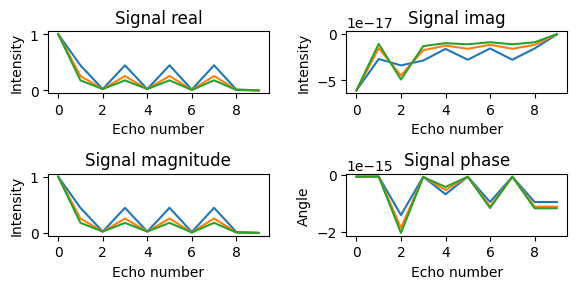

In [59]:
# Initialize sequence
sequence = SpinEchoSequence(alpha=np.pi, te=5, tr=300, reps=5)

# Create EPG object
epg = EPG(sequence, device='cpu')

# Define 3 tissue types
t1_list = torch.tensor([500, 1000, 1500])
t2_list = torch.tensor([100, 100, 100])

# Do simulation
epg.simulate(t1_list=t1_list, t2_list=t2_list)
echoes_batch = epg.find_echoes().cpu()

# Plot
plot_echoes(echoes_batch)

### Turbo Spin Echo

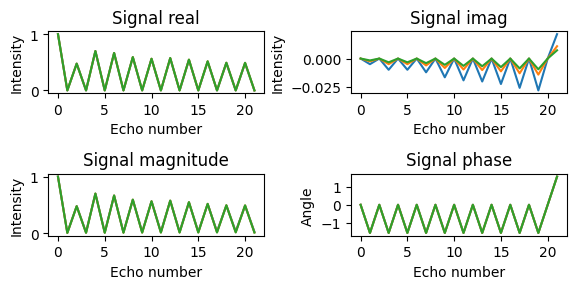

In [63]:
# Initialize sequence
sequence = TurboSpinEchoSequence(alpha=np.pi/2, etl=10, esp=5)

# Create EPG object
epg = EPG(sequence, device='cpu')

# Define 3 tissue types
t1_list = torch.tensor([500, 1000, 1500])
t2_list = torch.tensor([100, 100, 100])

# Do simulation
epg.simulate(t1_list=t1_list, t2_list=t2_list)
echoes_batch = epg.find_echoes().cpu()

# Plot
plot_echoes(echoes_batch)